In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [4]:
loan=pd.read_csv('loan_detection.csv')

In [5]:
loan.head()

,age,campaign,pdays,previous,no_previous_contact,not_working,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,Loan_Status_label
0,56,1,999,0,1,0,0,0,0,1,...,0,0,1,0,0,0,0,1,0,0
1,57,1,999,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
2,37,1,999,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
3,40,1,999,0,1,0,1,0,0,0,...,0,0,1,0,0,0,0,1,0,0
4,56,1,999,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0


In [6]:
loan.shape

(41188, 60)

In [7]:
loan.columns

Index(['age', 'campaign', 'pdays', 'previous', 'no_previous_contact',
       'not_working', 'job_admin.', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'job_unknown', 'marital_divorced', 'marital_married', 'marital_single',
       'marital_unknown', 'education_basic.4y', 'education_basic.6y',
       'education_basic.9y', 'education_high.school', 'education_illiterate',
       'education_professional.course', 'education_university.degree',
       'education_unknown', 'default_no', 'default_unknown', 'default_yes',
       'housing_no', 'housing_unknown', 'housing_yes', 'loan_no',
       'loan_unknown', 'loan_yes', 'contact_cellular', 'contact_telephone',
       'month_apr', 'month_aug', 'month_dec', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
       'day_of_week_fri', 'day_of_week_mon'

In [8]:
loan.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 60 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   age                            41188 non-null  int64
 1   campaign                       41188 non-null  int64
 2   pdays                          41188 non-null  int64
 3   previous                       41188 non-null  int64
 4   no_previous_contact            41188 non-null  int64
 5   not_working                    41188 non-null  int64
 6   job_admin.                     41188 non-null  int64
 7   job_blue-collar                41188 non-null  int64
 8   job_entrepreneur               41188 non-null  int64
 9   job_housemaid                  41188 non-null  int64
 10  job_management                 41188 non-null  int64
 11  job_retired                    41188 non-null  int64
 12  job_self-employed              41188 non-null  int64
 13  job_services               

In [9]:
loan.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.0,32.0,38.0,47.0,98.0
campaign,41188.0,2.567593,2.770014,1.0,1.0,2.0,3.0,56.0
pdays,41188.0,962.475454,186.910907,0.0,999.0,999.0,999.0,999.0
previous,41188.0,0.172963,0.494901,0.0,0.0,0.0,0.0,7.0
no_previous_contact,41188.0,0.963217,0.188230,0.0,1.0,1.0,1.0,1.0
not_working,41188.0,0.087623,0.282749,0.0,0.0,0.0,0.0,1.0
job_admin.,41188.0,0.253035,0.434756,0.0,0.0,0.0,1.0,1.0
job_blue-collar,41188.0,0.224677,0.417375,0.0,0.0,0.0,0.0,1.0
job_entrepreneur,41188.0,0.035350,0.184665,0.0,0.0,0.0,0.0,1.0
job_housemaid,41188.0,0.025736,0.158348,0.0,0.0,0.0,0.0,1.0


In [10]:
print('Columns (count) : ',len(loan.columns))
print('Missing values (top 15):')
display(loan.isnull().sum().sort_values(ascending=False).head(15))

Columns (count) :  60
Missing values (top 15):


age                    0
campaign               0
pdays                  0
previous               0
no_previous_contact    0
not_working            0
job_admin.             0
job_blue-collar        0
job_entrepreneur       0
job_housemaid          0
job_management         0
job_retired            0
job_self-employed      0
job_services           0
job_student            0
dtype: int64

# Detecting the target

Target distribution:


Loan_Status_label
0    36548
1     4640
Name: count, dtype: int64

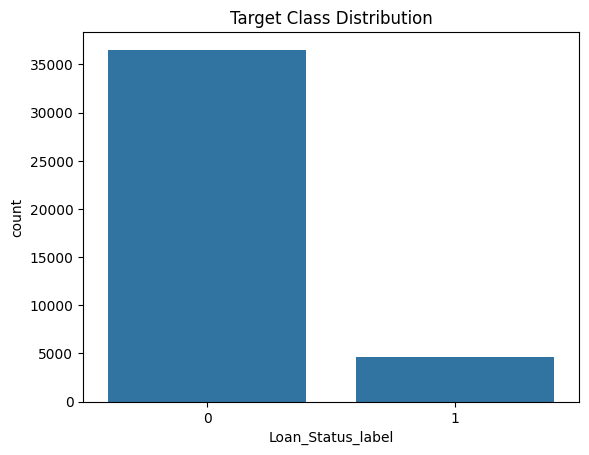

In [11]:
# Target check
target_col = 'Loan_Status_label'
print("Target distribution:")
display(loan[target_col].value_counts())
sns.countplot(x=target_col, data=loan)
plt.title("Target Class Distribution")
plt.show()

### Class Imbalance
The target variable is imbalanced, with the positive class representing approximately 11.3% of observations. Therefore, accuracy alone is not sufficient for evaluating the models. Precision, recall, F1-score, ROC-AUC and the Precision-Recall curve are considered.

# EDA

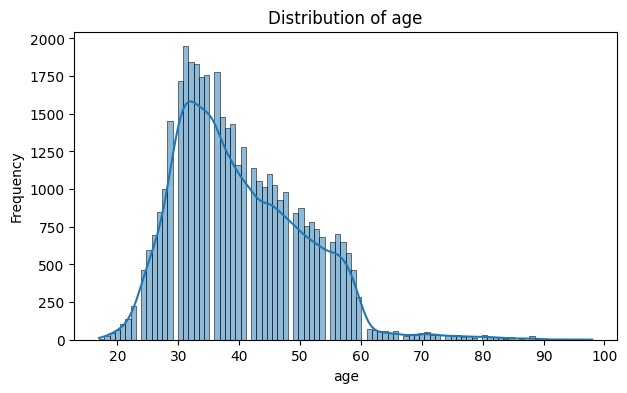

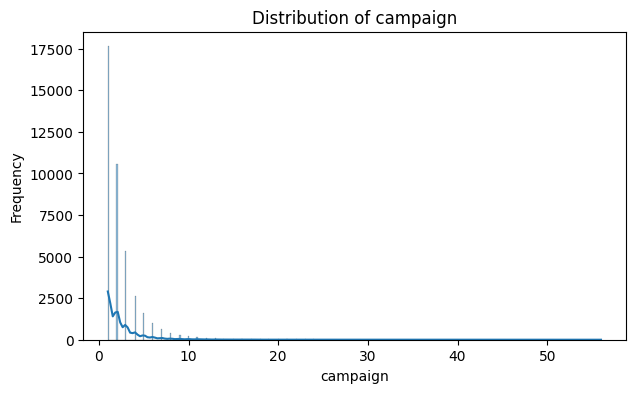

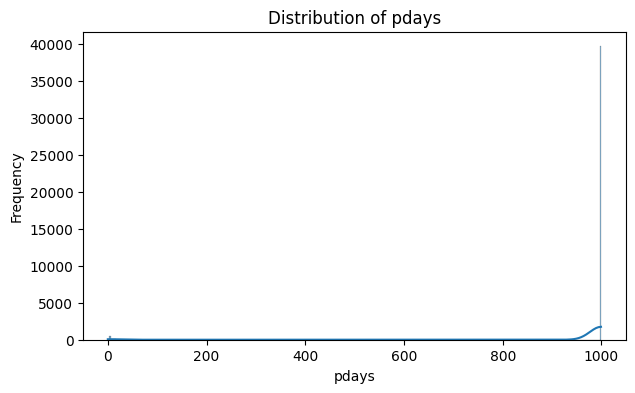

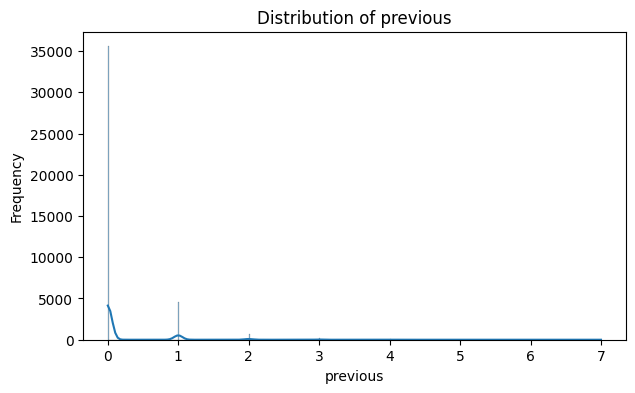

In [12]:
numeric_cols = [
    'age',
    'campaign',
    'pdays',
    'previous'
]
for col in numeric_cols:
    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=loan,
        x=col,
        kde=True
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

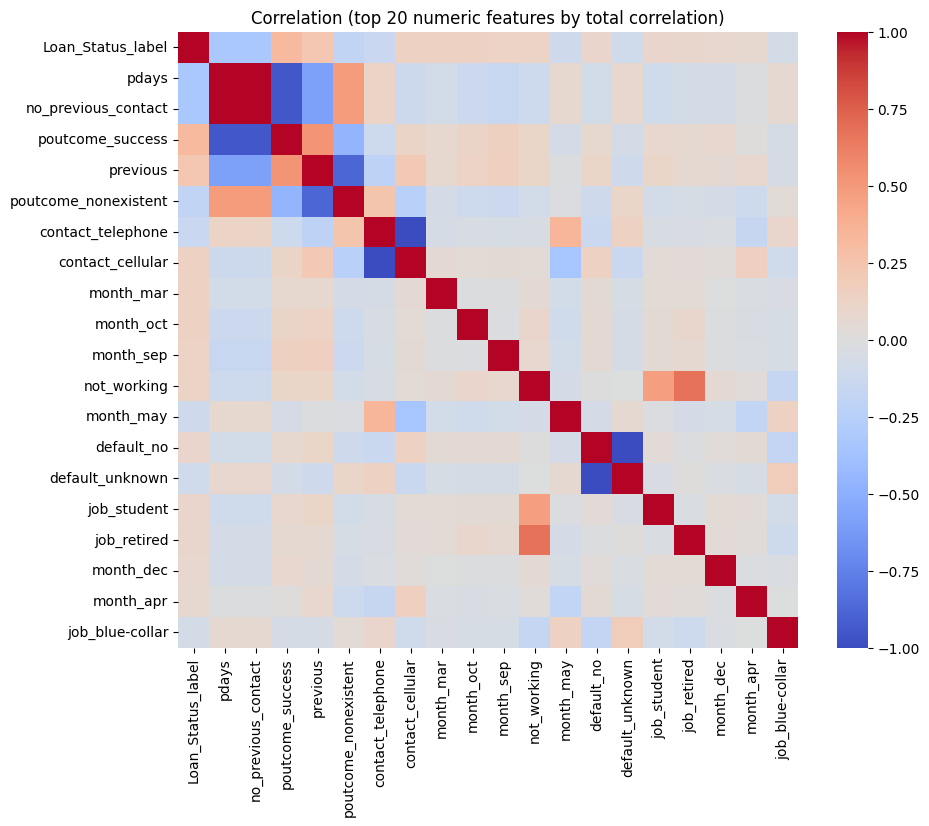

In [13]:
# Correlation heatmap for numeric features
corr_with_target = loan.corr(numeric_only=True)['Loan_Status_label']

# Select top 20 features based on correlation with target
top_corr = corr_with_target.abs().sort_values(ascending=False).head(20).index

plt.figure(figsize=(10, 8))

sns.heatmap(
    loan[top_corr].corr(),
    annot=False,
    cmap='coolwarm'
)

plt.title("Correlation (top 20 numeric features by total correlation)")
plt.show()

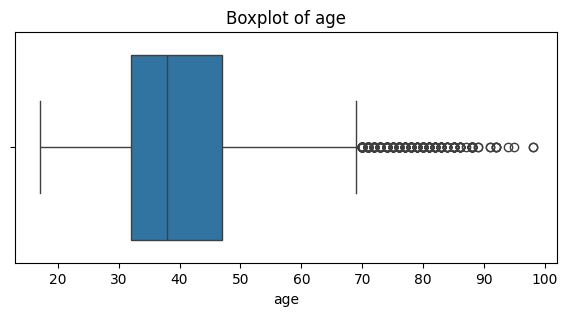

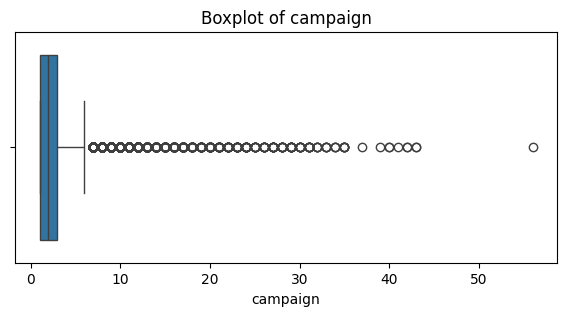

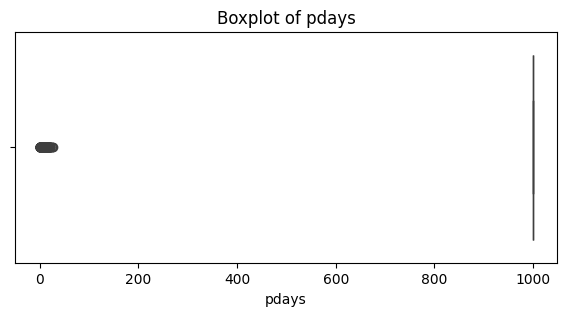

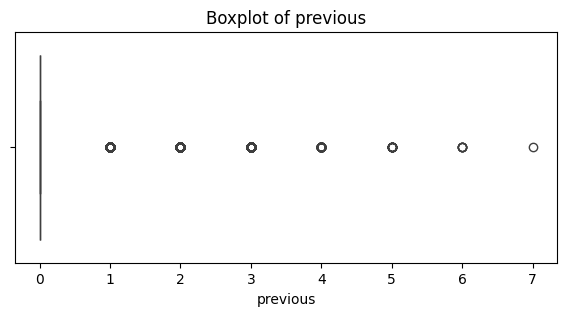

In [14]:
# Boxplots to check outliers for selected numeric features
for col in numeric_cols:
    plt.figure(figsize=(7, 3))

    sns.boxplot(x=loan[col])

    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

We'll let the model handle outliers unless there is evidence that they are data errors.

# Preprocessing and Feature Engineering

In [15]:
duplicate_count = loan.duplicated().sum()
loan = loan.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", loan.shape)

Shape after removing duplicates: (38771, 60)


In [16]:
# Basic preprocessing: fillna, scale numeric, leave categorical (one-hot already present)
target_col = 'Loan_Status_label'
X = loan.drop(columns=[target_col]).copy()
y = loan[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (31016, 59)
Testing data: (7755, 59)


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]),
            numeric_cols
        )
    ],
    remainder='passthrough'
)

# Models

In [18]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced'),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, random_state=42)
}

# Pipelining

In [19]:
pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

# Cross Validation

In [20]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
cv_results = {}

for name, pipeline in pipelines.items():

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring='f1',
        n_jobs=-1
    )

    cv_results[name] = scores

    print(
        f"{name}: "
        f"Mean F1 = {scores.mean():.4f}, "
        f"Std = {scores.std():.4f}"
    )


LogisticRegression: Mean F1 = 0.3890, Std = 0.0124
RandomForest: Mean F1 = 0.3850, Std = 0.0104
GradientBoosting: Mean F1 = 0.3205, Std = 0.0113


# Training and Evaluation of Models

In [21]:
results = {}

for name, pipeline in pipelines.items():

    print("=" * 60)
    print("Training:", name)

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)
    probabilities = pipeline.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )
    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )
    roc_auc = roc_auc_score(
        y_test,
        probabilities
    )

    results[name] = {
        'pipeline': pipeline,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc
    }

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc, 4))

Training: LogisticRegression
Accuracy : 0.7876
Precision: 0.2983
Recall   : 0.5871
F1 Score : 0.3956
ROC-AUC  : 0.7772
Training: RandomForest
Accuracy : 0.8587
Precision: 0.4015
Recall   : 0.3954
F1 Score : 0.3985
ROC-AUC  : 0.7403
Training: GradientBoosting
Accuracy : 0.8932
Precision: 0.652
Recall   : 0.2102
F1 Score : 0.318
ROC-AUC  : 0.7948


In [22]:
results_df = pd.DataFrame({
    name: {
        'Accuracy': result['accuracy'],
        'Precision': result['precision'],
        'Recall': result['recall'],
        'F1 Score': result['f1'],
        'ROC-AUC': result['roc_auc']
    }
    for name, result in results.items()
}).T

results_df = results_df.sort_values(
    by='F1 Score',
    ascending=False
)

results_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
RandomForest,0.858672,0.401549,0.395425,0.398463,0.740253
LogisticRegression,0.787621,0.298284,0.587146,0.395596,0.777198
GradientBoosting,0.893230,0.652027,0.210240,0.317957,0.794778


Confusion Matrix

In [23]:
best_name = results_df['F1 Score'].idxmax()

best_pipeline = results[best_name]['pipeline']

print("Best model based on F1 Score:", best_name)

Best model based on F1 Score: RandomForest


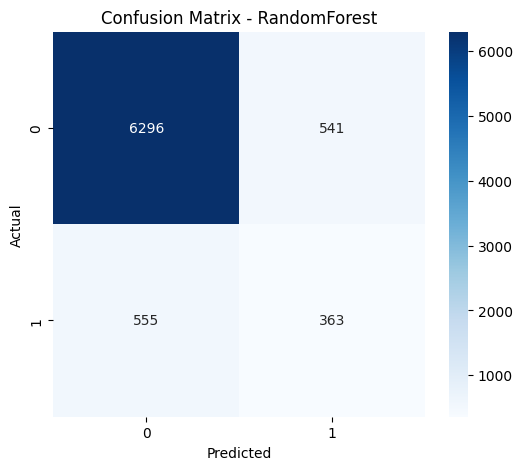

In [24]:
best_predictions = best_pipeline.predict(X_test)
cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(f"Confusion Matrix - {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Classification Report

In [25]:
print(
    classification_report(
        y_test,
        best_predictions,
        target_names=[
            'Not Approved',
            'Approved'
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

Not Approved       0.92      0.92      0.92      6837
    Approved       0.40      0.40      0.40       918

    accuracy                           0.86      7755
   macro avg       0.66      0.66      0.66      7755
weighted avg       0.86      0.86      0.86      7755



ROC Curve

<Figure size 800x600 with 0 Axes>

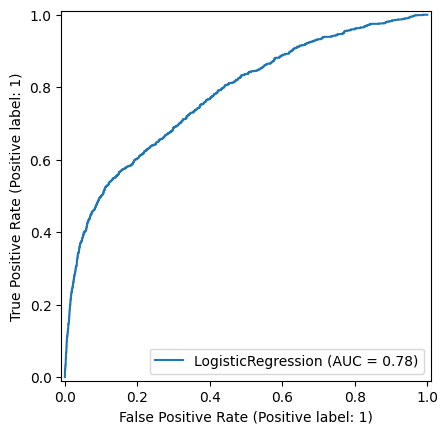

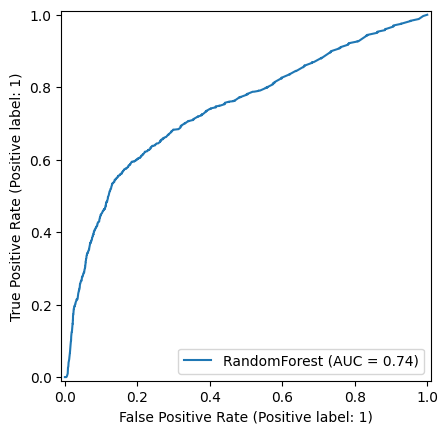

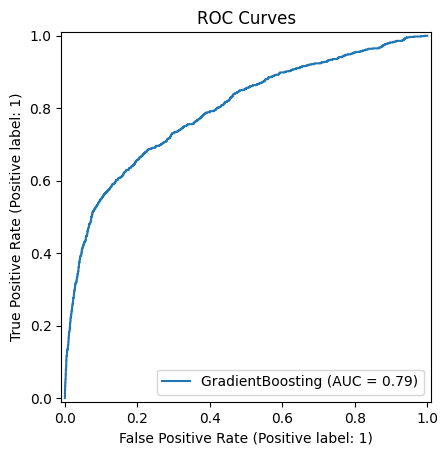

In [26]:
plt.figure(figsize=(8, 6))

for name, result in results.items():

    pipeline = result['pipeline']

    probabilities = pipeline.predict_proba(X_test)[:, 1]

    RocCurveDisplay.from_predictions(
        y_test,
        probabilities,
        name=name
    )

plt.title("ROC Curves")
plt.show()

Precision-Recall Curve

<Figure size 800x600 with 0 Axes>

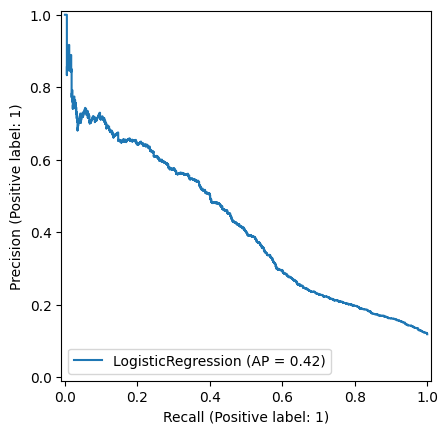

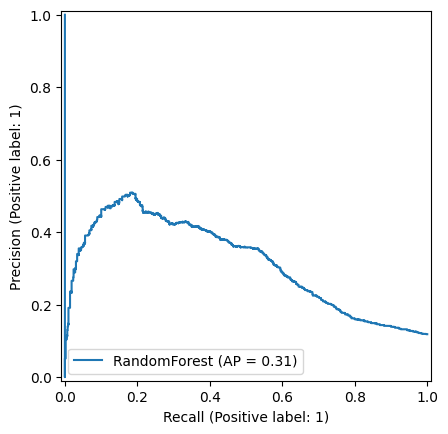

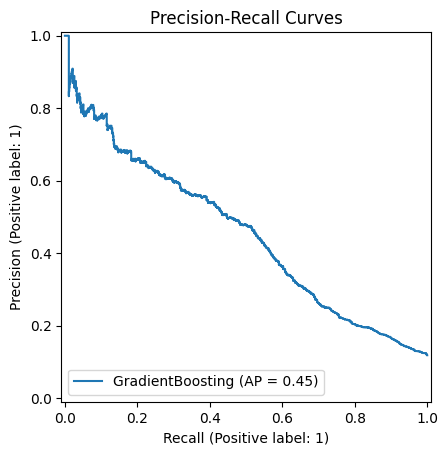

In [27]:
plt.figure(figsize=(8, 6))

for name, result in results.items():

    pipeline = result['pipeline']

    probabilities = pipeline.predict_proba(X_test)[:, 1]

    PrecisionRecallDisplay.from_predictions(
        y_test,
        probabilities,
        name=name
    )

plt.title("Precision-Recall Curves")
plt.show()

# Hyperparameter Tuning

FOR RANDOM FOREST

In [28]:
from sklearn.model_selection import RandomizedSearchCV
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    (
        'model',
        RandomForestClassifier(
            random_state=42,
            n_jobs=-1,
            class_weight='balanced'
        )
    )
])

In [29]:
rf_params = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

In [30]:
rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=20,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a be

In [31]:
print("Best parameters:")
print(rf_search.best_params_)

print("Best CV F1:")
print(rf_search.best_score_)

Best parameters:
{'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': 30}
Best CV F1:
0.4312880578867643


FOR GRADIENT BOOSTING

In [32]:
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    (
        'model',
        GradientBoostingClassifier(
            random_state=42
        )
    )
])

In [33]:
gb_params = {
    'model__n_estimators': [100, 150, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [2, 3, 4, 5],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

In [34]:
gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=gb_params,
    n_iter=20,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

gb_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best

COMPARISION

In [35]:
tuned_models = {
    'Tuned Random Forest': rf_search.best_estimator_,
    'Tuned Gradient Boosting': gb_search.best_estimator_
}

In [36]:
for name, model in tuned_models.items():

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    print("\n", "=" * 50)
    print(name)

    print(
        "Accuracy:",
        round(accuracy_score(y_test, predictions), 4)
    )

    print(
        "Precision:",
        round(precision_score(y_test, predictions), 4)
    )

    print(
        "Recall:",
        round(recall_score(y_test, predictions), 4)
    )

    print(
        "F1:",
        round(f1_score(y_test, predictions), 4)
    )

    print(
        "ROC-AUC:",
        round(roc_auc_score(y_test, probabilities), 4)
    )


Tuned Random Forest
Accuracy: 0.8346
Precision: 0.3688
Recall: 0.5588
F1: 0.4443
ROC-AUC: 0.7832

Tuned Gradient Boosting
Accuracy: 0.8913
Precision: 0.623
Recall: 0.207
F1: 0.3107
ROC-AUC: 0.791


In [37]:
all_models = {
    'Logistic Regression': pipelines['LogisticRegression'],
    'Random Forest': pipelines['RandomForest'],
    'Gradient Boosting': pipelines['GradientBoosting'],
    'Tuned Random Forest': rf_search.best_estimator_,
    'Tuned Gradient Boosting': gb_search.best_estimator_
}

In [38]:
final_scores = {}

for name, model in all_models.items():

    predictions = model.predict(X_test)

    final_scores[name] = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

final_scores_df = pd.DataFrame(
    list(final_scores.items()),
    columns=['Model', 'F1 Score']
).sort_values(
    by='F1 Score',
    ascending=False
)

final_scores_df

,Model,F1 Score
3,Tuned Random Forest,0.444348
1,Random Forest,0.398463
0,Logistic Regression,0.395596
2,Gradient Boosting,0.317957
4,Tuned Gradient Boosting,0.310711


In [39]:
final_model_name = final_scores_df.iloc[0]['Model']

final_model = all_models[final_model_name]

print("Final selected model:", final_model_name)

Final selected model: Tuned Random Forest


Model Selected - Tuned Random Forest

# Feature Importance(Tuned Random Forest)

In [41]:
rf_model = rf_search.best_estimator_

rf_classifier = rf_model.named_steps['model']

feature_importances = rf_classifier.feature_importances_

In [42]:
feature_names = rf_model.named_steps[
    'preprocessor'
].get_feature_names_out()

In [43]:
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head(15)

,Feature,Importance
0,num__age,0.126294
1,num__campaign,0.062321
2,num__pdays,0.056291
58,remainder__poutcome_success,0.048611
4,remainder__no_previous_contact,0.048379
39,remainder__contact_cellular,0.044114
40,remainder__contact_telephone,0.042620
3,num__previous,0.028223
47,remainder__month_may,0.026872
46,remainder__month_mar,0.024482


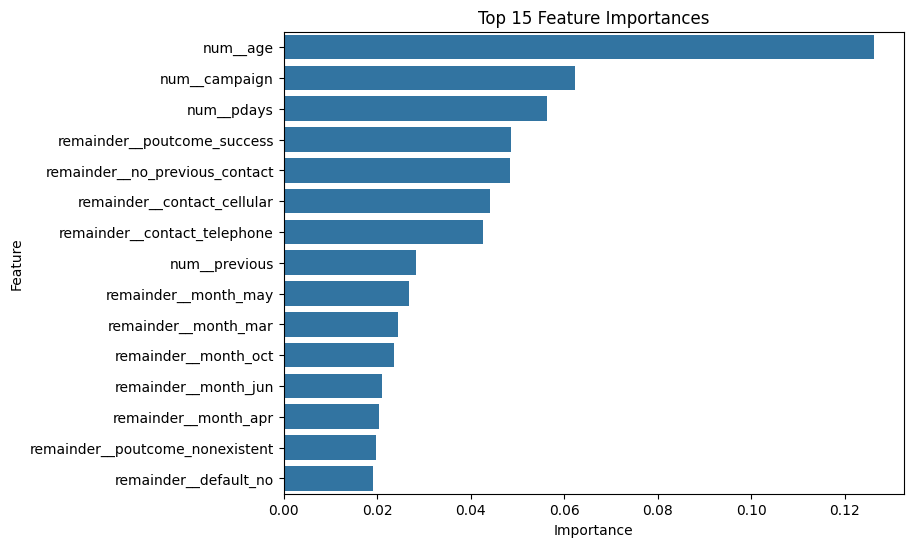

In [44]:
top_features = importance_df.head(15)

plt.figure(figsize=(8, 6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title("Top 15 Feature Importances")
plt.show()

# Threshold Analysis

In [45]:
probabilities = final_model.predict_proba(X_test)[:, 1]

threshold_results = []

for threshold in np.arange(0.20, 0.81, 0.05):

    predictions = (
        probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        'Threshold': threshold,
        'Precision': precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        'Recall': recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        'F1': f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.20,0.143431,0.933551,0.248658
1,0.25,0.162070,0.883442,0.273894
2,0.30,0.188424,0.819172,0.306376
3,0.35,0.220134,0.752723,0.340646
4,0.40,0.262385,0.680828,0.378788
5,0.45,0.320112,0.624183,0.423191
6,0.50,0.368799,0.558824,0.444348
7,0.55,0.418685,0.527233,0.466731
8,0.60,0.463265,0.494553,0.478398
9,0.65,0.492823,0.448802,0.469783


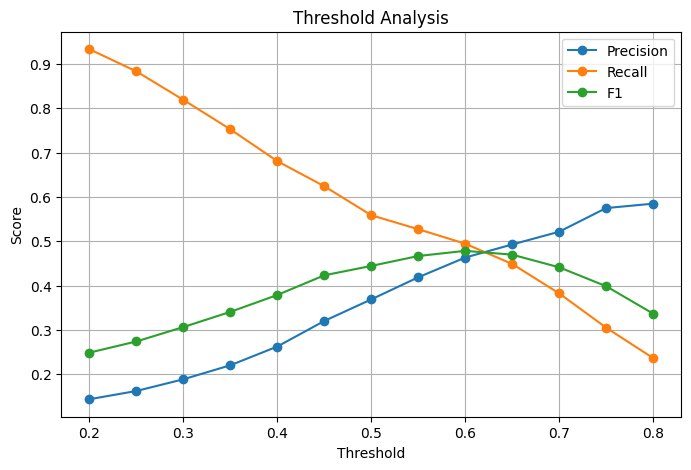

In [46]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df['Threshold'],
    threshold_df['Precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    threshold_df['Threshold'],
    threshold_df['Recall'],
    marker='o',
    label='Recall'
)

plt.plot(
    threshold_df['Threshold'],
    threshold_df['F1'],
    marker='o',
    label='F1'
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis")
plt.legend()
plt.grid()

plt.show()

In [47]:
best_threshold = threshold_df.loc[
    threshold_df['F1'].idxmax(),
    'Threshold'
]

print("Best threshold:", best_threshold)

Best threshold: 0.5999999999999999


Although 0.55 gives a slightly better F1-score, **0.50 was selected as the final threshold because it is the standard, simple, and interpretable probability cutoff for binary classification.**


# Final Evaluation Cell

In [48]:
final_predictions = (
    final_model.predict(X_test)
)

final_probabilities = (
    final_model.predict_proba(X_test)[:, 1]
)

print("Final Model:", final_model_name)
print("-" * 50)

print(
    "Accuracy :",
    round(
        accuracy_score(
            y_test,
            final_predictions
        ),
        4
    )
)

print(
    "Precision:",
    round(
        precision_score(
            y_test,
            final_predictions,
            zero_division=0
        ),
        4
    )
)

print(
    "Recall   :",
    round(
        recall_score(
            y_test,
            final_predictions,
            zero_division=0
        ),
        4
    )
)

print(
    "F1 Score :",
    round(
        f1_score(
            y_test,
            final_predictions,
            zero_division=0
        ),
        4
    )
)

print(
    "ROC-AUC  :",
    round(
        roc_auc_score(
            y_test,
            final_probabilities
        ),
        4
    )
)

Final Model: Tuned Random Forest
--------------------------------------------------
Accuracy : 0.8346
Precision: 0.3688
Recall   : 0.5588
F1 Score : 0.4443
ROC-AUC  : 0.7832


In [50]:
import joblib
import sklearn

print("scikit-learn version:", sklearn.__version__)

joblib.dump(final_model, "best_pipeline.pkl")

print("Model saved successfully.")

scikit-learn version: 1.9.0
Model saved successfully.


In [51]:
import joblib
from sklearn.metrics import f1_score, roc_auc_score

loaded_model = joblib.load("best_pipeline.pkl")

test_predictions = loaded_model.predict(X_test)
test_probabilities = loaded_model.predict_proba(X_test)[:, 1]

print("Model loaded successfully.")
print("Input shape:", X_test.shape)

print("F1 Score:", round(f1_score(y_test, test_predictions), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, test_probabilities), 4))

Model loaded successfully.
Input shape: (7755, 59)
F1 Score: 0.4443
ROC-AUC: 0.7832


In [52]:
# Get the exact feature names expected by the trained pipeline

feature_names = loaded_model.named_steps[
    "preprocessor"
].get_feature_names_out()

print("Number of features:", len(feature_names))

for i, feature in enumerate(feature_names, start=1):
    print(i, feature)

Number of features: 59
1 num__age
2 num__campaign
3 num__pdays
4 num__previous
5 remainder__no_previous_contact
6 remainder__not_working
7 remainder__job_admin.
8 remainder__job_blue-collar
9 remainder__job_entrepreneur
10 remainder__job_housemaid
11 remainder__job_management
12 remainder__job_retired
13 remainder__job_self-employed
14 remainder__job_services
15 remainder__job_student
16 remainder__job_technician
17 remainder__job_unemployed
18 remainder__job_unknown
19 remainder__marital_divorced
20 remainder__marital_married
21 remainder__marital_single
22 remainder__marital_unknown
23 remainder__education_basic.4y
24 remainder__education_basic.6y
25 remainder__education_basic.9y
26 remainder__education_high.school
27 remainder__education_illiterate
28 remainder__education_professional.course
29 remainder__education_university.degree
30 remainder__education_unknown
31 remainder__default_no
32 remainder__default_unknown
33 remainder__default_yes
34 remainder__housing_no
35 remainder__